# Losses per Position — PP8/EP2 min64k repro (cp=1, no CP)

Attempt to repro the LPS-1003 rep0-vs-rep1 destruction bug on **pp8/ep2 @ 64k with cp=1** (no context parallelism).
**Result: NO repro.** 5/5 reps clean — CP is load-bearing for the bug.

- **2 datums** × 49,999 positions each (prefix=32, supervised positions 31–49998)
  - datum 0: palindrome text ("ABCDEFEDCBA" repeated)
  - datum 1: random 256-token chunk tiled to 50k
- **5 reps** (rep0–rep4), all clean (`destroyed = {}`)
- Run: `min64k_0731_234442/` inside `min64k/`


In [1]:
import gzip, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Resolve run dir from the notebook's own location
RUN_DIR = Path('../../../min64k/min64k_0731_234442')  # relative to parity/runs/attrib_conn/
if not RUN_DIR.exists():
    # Fallback: search from cwd
    for cand in [Path('../../../experiment_artefacts/glm/lps1003_loss_spikes/min64k/min64k_0731_234442'),
                 Path('../../experiment_artefacts/glm/lps1003_loss_spikes/min64k/min64k_0731_234442')]:
        if cand.exists():
            RUN_DIR = cand
            break
RUN_DIR = RUN_DIR.resolve()

N_REPS = 5
PREFIX = 32  # first 31 positions are weight=0 (unsupervised)
DATUM_LABELS = ['palindrome', 'random-tile']

reps = {}
for r in range(N_REPS):
    p = RUN_DIR / f'min64k_window_rep{r}.json.gz'
    reps[r] = json.load(gzip.open(p))
    print(f"rep{r}: nlls={[f'{x:.6f}' for x in reps[r]['nlls']]}  destroyed={reps[r]['destroyed']}")

rep0: nlls=['0.000115', '0.167470']  destroyed={}
rep1: nlls=['0.000121', '0.167495']  destroyed={}
rep2: nlls=['0.000113', '0.164290']  destroyed={}
rep3: nlls=['0.000117', '0.162743']  destroyed={}
rep4: nlls=['0.000131', '0.161918']  destroyed={}


### Plot 1 — Per-position NLL: rep0 vs rep1 (both datums)


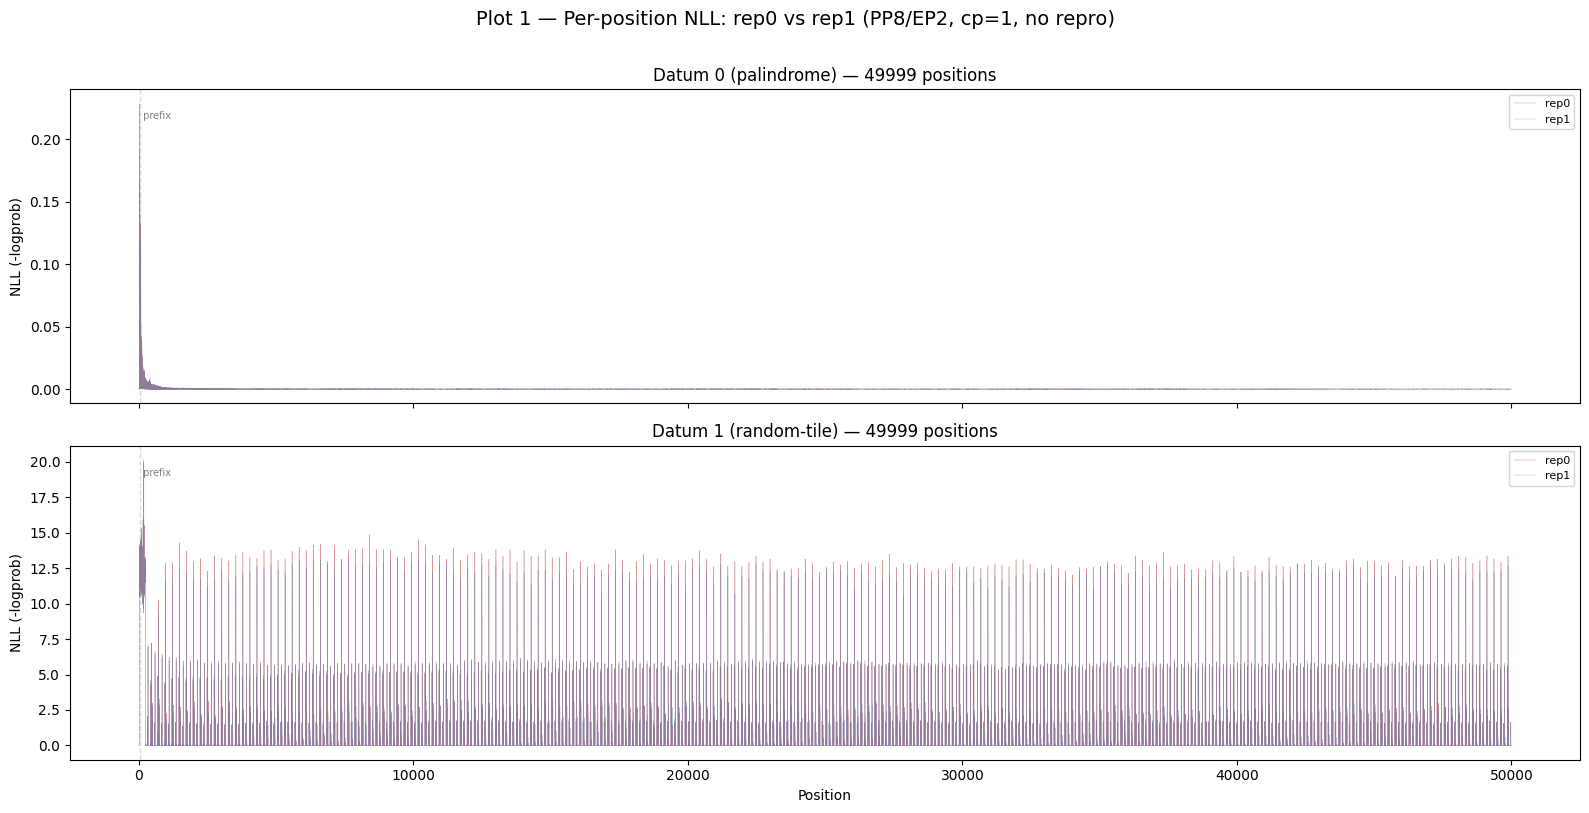

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for di, ax in enumerate(axes):
    nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
    nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
    x = np.arange(len(nll0))

    ax.plot(x, nll0, color='#C44E52', linewidth=0.3, alpha=0.7, label='rep0')
    ax.plot(x, nll1, color='#4C72B0', linewidth=0.3, alpha=0.5, label='rep1')

    # Mark prefix boundary
    ax.axvline(PREFIX - 1, color='gray', alpha=0.3, linestyle='--', linewidth=1)
    ax.text(PREFIX - 1, ax.get_ylim()[1] * 0.9, ' prefix', fontsize=7, color='gray')

    ax.set_ylabel('NLL (-logprob)')
    ax.set_title(f'Datum {di} ({DATUM_LABELS[di]}) — {len(nll0)} positions')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position')
fig.suptitle('Plot 1 — Per-position NLL: rep0 vs rep1 (PP8/EP2, cp=1, no repro)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Plot 2 — Per-rep NLL (bar chart)


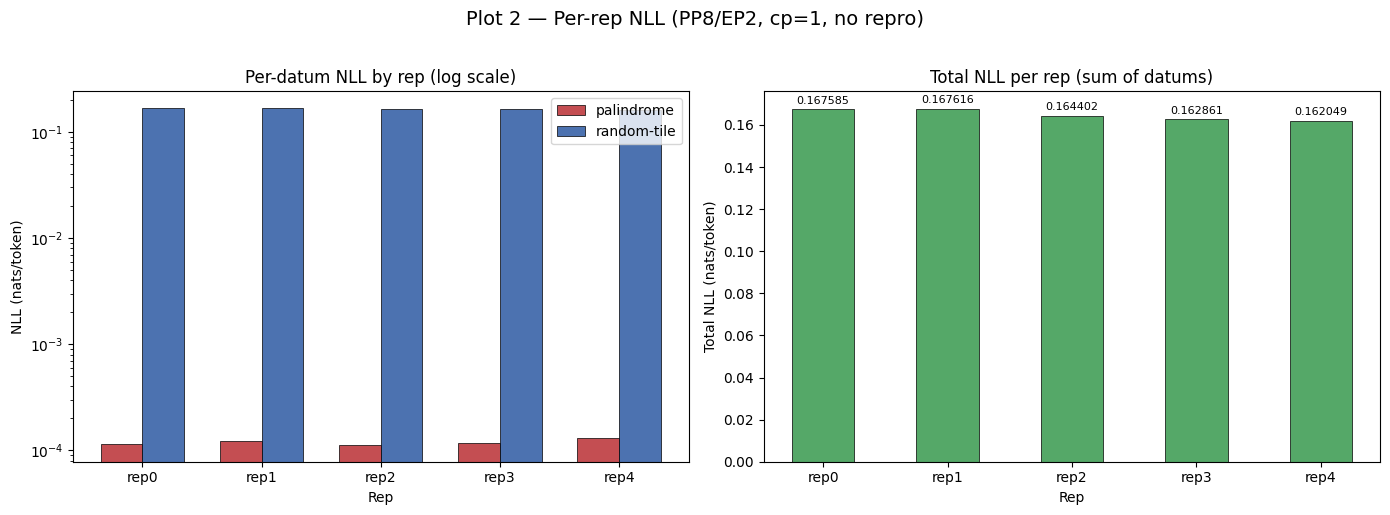

In [3]:
n_datums = len(reps[0]['nlls'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-datum NLL per rep (log scale — palindrome is ~1000x smaller)
x = np.arange(N_REPS)
width = 0.35
colors = ['#C44E52', '#4C72B0']
for di in range(n_datums):
    vals = [reps[r]['nlls'][di] for r in range(N_REPS)]
    offset = (di - n_datums/2 + 0.5) * width
    ax1.bar(x + offset, vals, width, label=DATUM_LABELS[di],
            color=colors[di], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Rep')
ax1.set_ylabel('NLL (nats/token)')
ax1.set_title('Per-datum NLL by rep (log scale)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'rep{r}' for r in range(N_REPS)])
ax1.set_yscale('log')
ax1.legend()

# Right: total NLL per rep (sum of datums)
totals = [sum(reps[r]['nlls']) for r in range(N_REPS)]
bars = ax2.bar(x, totals, width=0.5, color='#55A868', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Rep')
ax2.set_ylabel('Total NLL (nats/token)')
ax2.set_title('Total NLL per rep (sum of datums)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'rep{r}' for r in range(N_REPS)])
# Add value labels
for bar, val in zip(bars, totals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val:.6f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Plot 2 — Per-rep NLL (PP8/EP2, cp=1, no repro)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### Plot 3 — Per-position |ΔNLL|: rep0 vs rep1 (both datums)


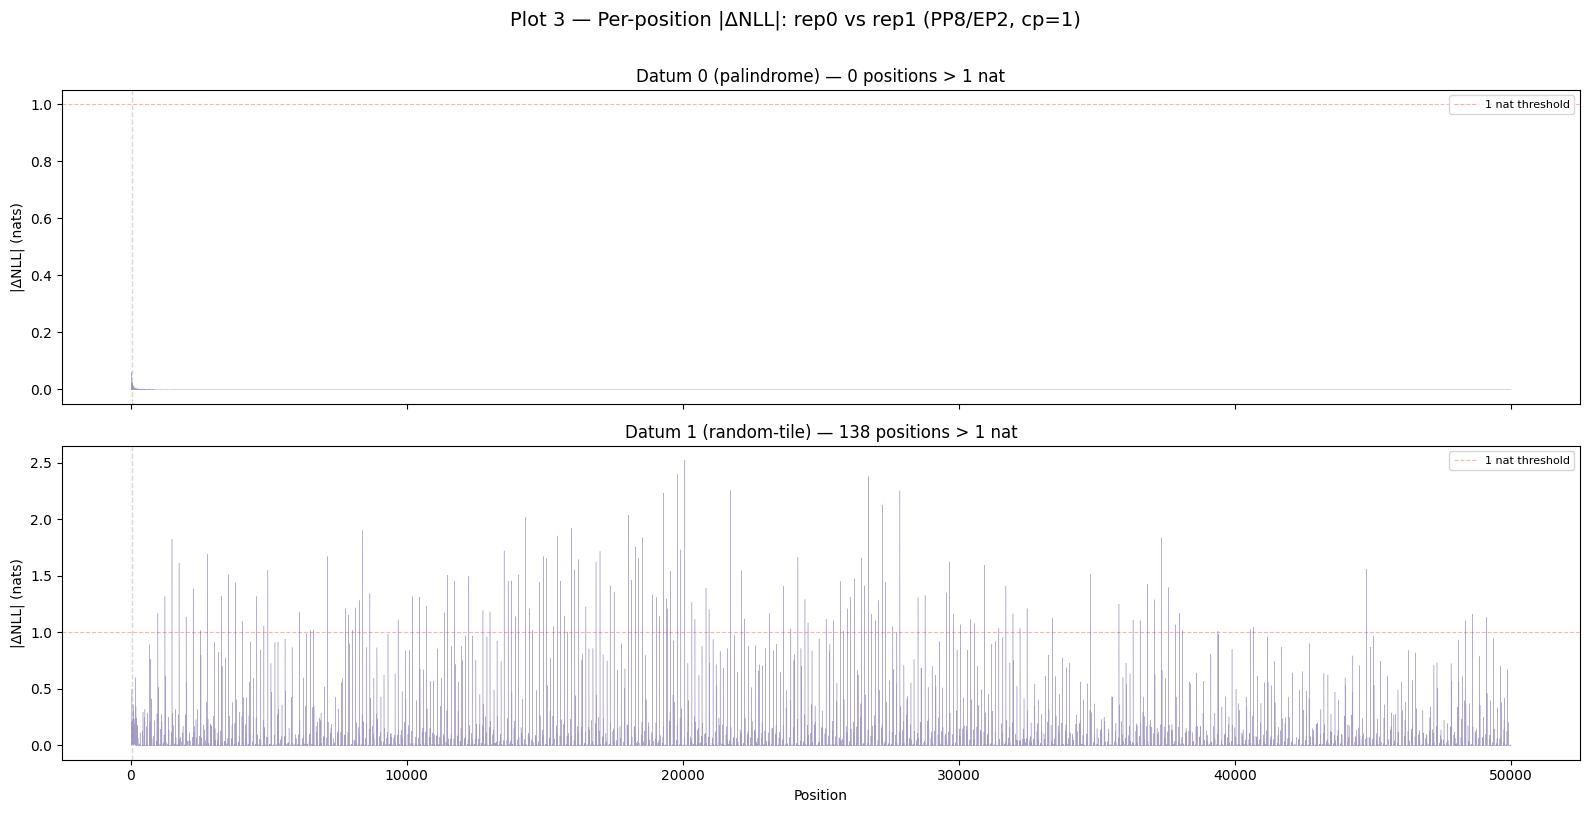

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for di, ax in enumerate(axes):
    nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
    nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
    delta = np.abs(nll0 - nll1)
    x = np.arange(len(delta))

    ax.plot(x, delta, color='#8172B3', linewidth=0.3, alpha=0.7)
    ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')

    ax.axvline(PREFIX - 1, color='gray', alpha=0.3, linestyle='--', linewidth=1)

    n_big = int((delta[PREFIX-1:] > 1.0).sum())
    ax.set_ylabel('|ΔNLL| (nats)')
    ax.set_title(f'Datum {di} ({DATUM_LABELS[di]}) — {n_big} positions > 1 nat')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position')
fig.suptitle('Plot 3 — Per-position |ΔNLL|: rep0 vs rep1 (PP8/EP2, cp=1)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

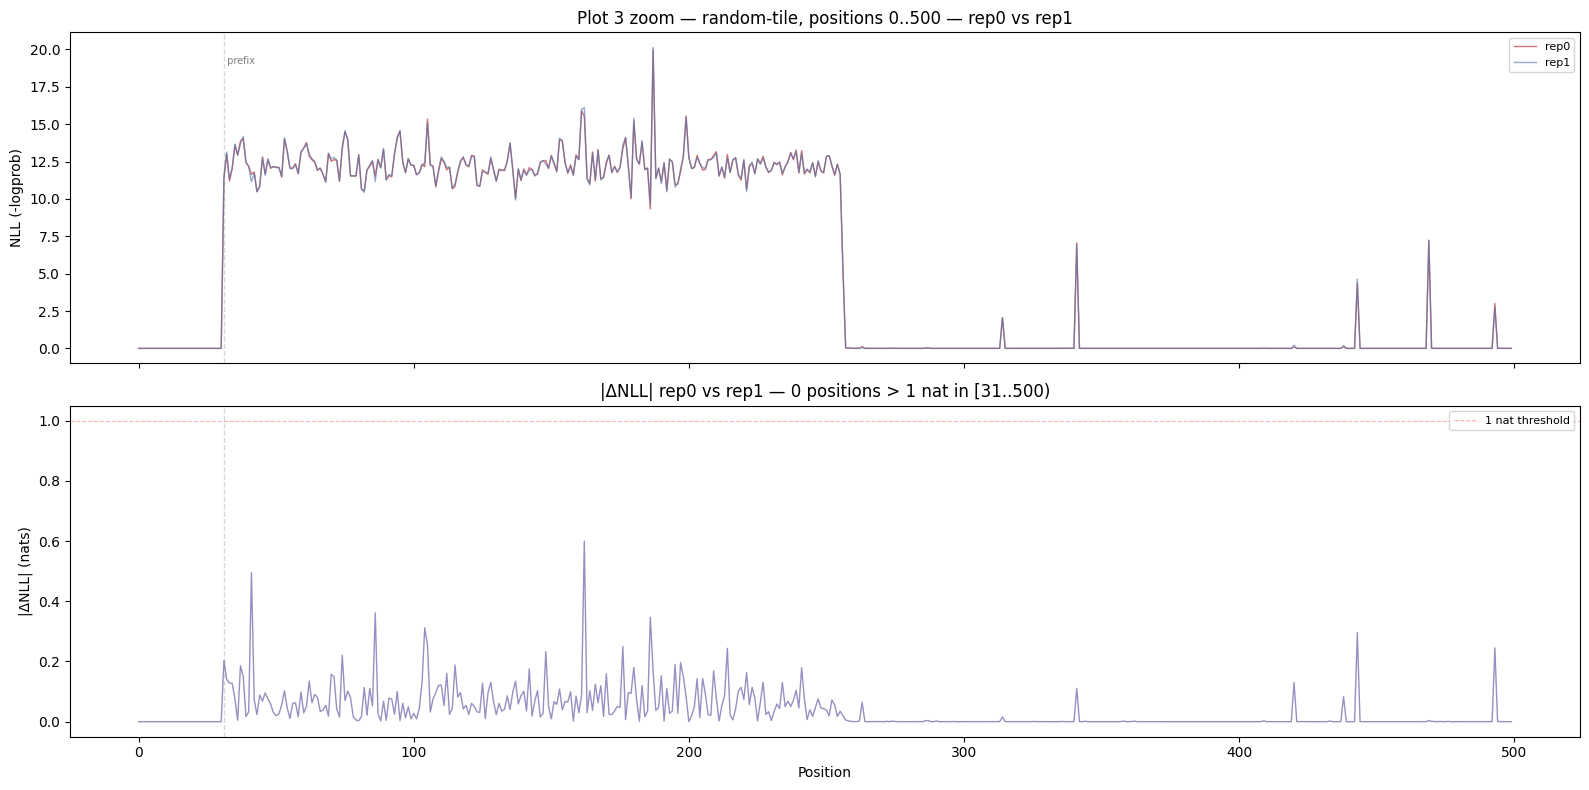

In [5]:
# Plot 3 zoom — random-tile (datum 1), positions 0..500
ZOOM_END = 500
di = 1  # random-tile

nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
delta = np.abs(nll0 - nll1)
x = np.arange(len(delta))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: per-position NLL for rep0 and rep1
ax = axes[0]
ax.plot(x[:ZOOM_END], nll0[:ZOOM_END], color='#C44E52', linewidth=1.0, alpha=0.8, label='rep0')
ax.plot(x[:ZOOM_END], nll1[:ZOOM_END], color='#4C72B0', linewidth=1.0, alpha=0.6, label='rep1')
ax.axvline(PREFIX - 1, color='gray', alpha=0.3, linestyle='--', linewidth=1)
ax.text(PREFIX - 1, ax.get_ylim()[1] * 0.9, ' prefix', fontsize=7, color='gray')
ax.set_ylabel('NLL (-logprob)')
ax.set_title(f'Plot 3 zoom — {DATUM_LABELS[di]}, positions 0..{ZOOM_END} — rep0 vs rep1')
ax.legend(loc='upper right', fontsize=8)

# Bottom: |ΔNLL|
ax = axes[1]
ax.plot(x[:ZOOM_END], delta[:ZOOM_END], color='#8172B3', linewidth=1.0, alpha=0.8)
ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')
ax.axvline(PREFIX - 1, color='gray', alpha=0.3, linestyle='--', linewidth=1)
n_big = int((delta[PREFIX-1:ZOOM_END] > 1.0).sum())
ax.set_ylabel('|ΔNLL| (nats)')
ax.set_xlabel('Position')
ax.set_title(f'|ΔNLL| rep0 vs rep1 — {n_big} positions > 1 nat in [{PREFIX-1}..{ZOOM_END})')
ax.legend(loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()

### Summary

| datum | rep0 | rep1 | rep2 | rep3 | rep4 | max|ΔNLL| vs rep0 |
|---|---|---|---|---|---|---|


In [6]:
# Print summary table (markdown-friendly)
for i in range(len(reps[0]['nlls'])):
    row = [reps[r]['nlls'][i] for r in range(N_REPS)]
    rest = row[1:]
    dmax = max(abs(row[0] - v) for v in rest) if rest else 0.0
    label = DATUM_LABELS[i] if i < len(DATUM_LABELS) else f'd{i}'
    print(f'{label:<12}' + ''.join(f'{v:<12.6f}' for v in row) + f'{dmax:.6f}')
print()
print('VERDICT: clean — no rep0-vs-rest destruction above 2 nats')

palindrome  0.000115    0.000121    0.000113    0.000117    0.000131    0.000016
random-tile 0.167470    0.167495    0.164290    0.162743    0.161918    0.005552

VERDICT: clean — no rep0-vs-rest destruction above 2 nats
